# 📓 Step 04 — Byte-Level BPE (BBPE) Tokenizer

> *"For the data encoded with PPFLE, we employed the ByteLevelBPETokenizer*
> *from the Hugging Face Transformers library. This tokenizer, initially utilized*
> *for GPT-2, breaks down text into subword units for tokenization."*
> — SecurityBERT Paper, Section III-D

---

## 🎯 Objective
Train a **ByteLevelBPETokenizer** on the PPFLE-encoded corpus and tokenize
all sequences into `input_ids` + `attention_masks` ready for SecurityBERT.

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load PPFLE-encoded dataset | DataFrame |
| 3 | Understand BBPE — theory & motivation | — |
| 4 | Export corpus for tokenizer training | `tokenizer/corpus.txt` |
| 5 | Train ByteLevelBPETokenizer | `tokenizer/vocab.json`, `merges.txt` |
| 6 | Inspect trained tokenizer | Vocabulary analysis |
| 7 | Tokenize full dataset → input_ids + masks | `tokenized_sequences.pt` |
| 8 | Validate tokenized output | Sequence stats |
| 9 | Visualize tokenization | Charts |
| 10 | Save tokenized dataset | `data/processed/tokenized_sequences.pt` |

---

## 🔬 BBPE — How it Works

**Byte-Pair Encoding (BPE)** is a data compression algorithm adapted for NLP:
1. Start with individual bytes/characters as the vocabulary
2. Find the most frequent pair of consecutive tokens
3. Merge that pair into a new single token
4. Repeat until vocabulary size is reached

**Why ByteLevel BPE for PPFLE data?**
- PPFLE produces 32-char MD5 hex strings → not in any human-language vocabulary
- BBPE operates at the **byte level** → handles any sequence of characters
- Breaks hex tokens into **subword units** that BERT can embed
- Handles **OOV (out-of-vocabulary)** perfectly — no unknown tokens

**Paper Parameters:**
| Parameter | Value |
|-----------|-------|
| Vocabulary size | **5,000** |
| Minimum frequency | **2** |
| Special tokens | `<s>`, `<pad>`, `</s>`, `<unk>`, `<mask>` |
| Base algorithm | Byte-Pair Encoding (GPT-2 style) |

---

## 🖼️ Figure 4 — Paper Example

```
CSV Input:
  HTTP.METHOD  TCP.ACK  TCP.ACK_RAW  TCP.DSTPORT
  GET          1        2649986338   80
  POST         13       1815315521   443

After PPFLE:
  H(HTTP.METHOD$GET) H(TCP.ACK$1) H(TCP.ACK_RAW$2649986338) H(TCP.DSTPORT$80)
  H(HTTP.METHOD$POST) H(TCP.ACK$13) H(TCP.ACK_RAW$1815315521) H(TCP.DSTPORT$443)

After BBPE Tokenization (token IDs):
  [40, 318, 38, 1484, 39, 40, ...]
  [22, 42, 40, 42, 22, 39, ...]
```
> ⚠️ Input: `data/processed/ppfle_encoded.csv` from Notebook 03

## 🧱 Step 1 — Imports & Setup

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import gc
import json
import time
import os
from pathlib import Path
from collections import Counter

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Hugging Face tokenizers ───────────────────────────────────────────────────
from tokenizers import ByteLevelBPETokenizer
from tokenizers.processors import BertProcessing

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 120)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR     = Path('..')
DATA_DIR     = BASE_DIR / 'data'
PROC_DIR     = DATA_DIR / 'processed'
TOK_DIR      = BASE_DIR / 'tokenizer'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N4'

INPUT_PATH   = PROC_DIR / 'ppfle_encoded.csv'
CORPUS_PATH  = TOK_DIR  / 'corpus.txt'
VOCAB_PATH   = TOK_DIR  / 'vocab.json'
MERGES_PATH  = TOK_DIR  / 'merges.txt'
OUTPUT_PATH  = PROC_DIR / 'tokenized_sequences.pt'

TOK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Tokenizer parameters (directly from the paper) ────────────────────────────
VOCAB_SIZE     = 5_000
MIN_FREQUENCY  = 2
MAX_SEQ_LEN    = 512         # paper: truncation max length = 512
SPECIAL_TOKENS = ['<s>', '<pad>', '</s>', '<unk>', '<mask>']
TARGET_COLUMN  = 'Attack_type'
CHUNK_SIZE     = 50_000
RANDOM_STATE   = 42

print('✅ Environment ready.')
print(f'   pandas        : {pd.__version__}')
print(f'   numpy         : {np.__version__}')
try:
    import tokenizers
    print(f'   tokenizers    : {tokenizers.__version__}')
except:
    print('   tokenizers    : ❌ not found — install: pip install tokenizers')
print()
print('📐 Tokenizer config (from paper):')
print(f'   Vocabulary size   : {VOCAB_SIZE:,}')
print(f'   Min frequency     : {MIN_FREQUENCY}')
print(f'   Max sequence len  : {MAX_SEQ_LEN}')
print(f'   Special tokens    : {SPECIAL_TOKENS}')
print(f'   Input             : {INPUT_PATH}')
print(f'   Tokenizer dir     : {TOK_DIR}')

✅ Environment ready.
   pandas        : 3.0.2
   numpy         : 2.4.3
   tokenizers    : 0.22.2

📐 Tokenizer config (from paper):
   Vocabulary size   : 5,000
   Min frequency     : 2
   Max sequence len  : 512
   Special tokens    : ['<s>', '<pad>', '</s>', '<unk>', '<mask>']
   Input             : ..\data\processed\ppfle_encoded.csv
   Tokenizer dir     : ..\tokenizer


## 📂 Step 2 — Load PPFLE-Encoded Dataset

In [2]:
assert INPUT_PATH.exists(), (
    f'❌ File not found: {INPUT_PATH.resolve()}\n'
    f'   Please run Notebook 03 (PPFLE Encoding) first.'
)

print(f'📁 File size : {INPUT_PATH.stat().st_size / 1e6:.1f} MB')
print('🔄 Loading PPFLE-encoded dataset …')

chunks = []
for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f'✅ Loaded  {len(df):,} rows × {df.shape[1]} columns')
print(f'   RAM    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'   Columns: {list(df.columns)}')

# ── Inspect a sample sequence ─────────────────────────────────────────────────
sample_seq    = str(df['encoded_sequence'].iloc[0])
sample_tokens = sample_seq.split()
print(f'\n🔬 Sample sequence (row 0):')
print(f'   Total tokens  : {len(sample_tokens)}  (= PPFLE features)')
print(f'   Token length  : {len(sample_tokens[0])} chars  (MD5 hex)')
print(f'   Total chars   : {len(sample_seq)}')
print(f'   First 3 tokens: {sample_tokens[:3]}')
print(f'   Label         : {df[TARGET_COLUMN].iloc[0]}')

📁 File size : 3387.6 MB
🔄 Loading PPFLE-encoded dataset …
✅ Loaded  2,218,386 rows × 2 columns
   RAM    : 3598.4 MB
   Columns: ['encoded_sequence', 'Attack_type']

🔬 Sample sequence (row 0):
   Total tokens  : 46  (= PPFLE features)
   Token length  : 32 chars  (MD5 hex)
   Total chars   : 1517
   First 3 tokens: ['d9252e545bcd59c92c2bfb791747a6ec', '0c7aa67cfed12e80f1a0b583d26f47e8', 'bf7d1a9c6757ab815c7ed29ce3d668b8']
   Label         : Normal


## 🔬 Step 3 — BBPE Theory & Motivation

### Why not use a standard BERT tokenizer?
Standard BERT uses **WordPiece** tokenization trained on English text.
PPFLE sequences contain **MD5 hex strings** — completely foreign to English vocabulary.

### Why BBPE works for PPFLE data
- Operates at **byte level** → any character sequence is valid input
- Builds vocabulary from the **actual PPFLE corpus** → learns hex subword patterns
- Same hex prefix across different attacks → shared subword tokens → context learning
- **OOV impossible** → every byte is representable

### The key insight from the paper
> *"The hash output for a specific attack remains constant; thus, if these subword*
> *hexadecimal values appear in a particular sequence, BERT can recognize that this*
> *unique order corresponds to a hash output and categorize it as a specific attack."*

This means:
- `H(TCP.DSTPORT$443)` always produces the **same 32-char hex token**
- BBPE splits this into consistent **subword units**
- SecurityBERT learns to associate **subword patterns** with **attack types**

### Vocabulary Size = 5,000
The paper chose 5,000 deliberately:
- Large enough to cover hex subword patterns across all 14 attack types
- Small enough to keep the model compact (11M parameters total)
- Matches the training data: **661,767,168 tokens** total corpus

## 📄 Step 4 — Export Corpus for Tokenizer Training

The `ByteLevelBPETokenizer` requires a **plain text file** as training corpus —
one sequence per line. We write all PPFLE-encoded sequences to `tokenizer/corpus.txt`.

In [3]:
print(f'📝 Writing corpus to {CORPUS_PATH} …')
print(f'   Total sequences : {len(df):,}')

t_start = time.time()

with open(CORPUS_PATH, 'w', encoding='utf-8') as f:
    for i, seq in enumerate(df['encoded_sequence']):
        f.write(str(seq).strip() + '\n')
        if (i + 1) % 500_000 == 0:
            elapsed = time.time() - t_start
            print(f'   … {i+1:,} sequences written  ({elapsed:.1f}s)')

elapsed = time.time() - t_start
corpus_size_mb = CORPUS_PATH.stat().st_size / 1e6

print(f'\n✅ Corpus written.')
print(f'   Path       : {CORPUS_PATH.resolve()}')
print(f'   Lines      : {len(df):,}')
print(f'   Size       : {corpus_size_mb:.1f} MB')
print(f'   Time       : {elapsed:.1f}s')

# ── Quick corpus sanity check ──────────────────────────────────────────────────
with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    first_lines = [f.readline().strip() for _ in range(3)]

print(f'\n🔬 First 3 corpus lines:')
for i, line in enumerate(first_lines):
    toks = line.split()
    print(f'   Line {i+1}: {len(toks)} tokens | first token: {toks[0]} | last: {toks[-1]}')

📝 Writing corpus to ..\tokenizer\corpus.txt …
   Total sequences : 2,218,386
   … 500,000 sequences written  (1.9s)
   … 1,000,000 sequences written  (3.5s)
   … 1,500,000 sequences written  (5.1s)
   … 2,000,000 sequences written  (7.0s)

✅ Corpus written.
   Path       : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\tokenizer\corpus.txt
   Lines      : 2,218,386
   Size       : 3369.7 MB
   Time       : 7.7s

🔬 First 3 corpus lines:
   Line 1: 46 tokens | first token: d9252e545bcd59c92c2bfb791747a6ec | last: bd1d6c946639fa8d8ddafc3594305b12
   Line 2: 46 tokens | first token: d9252e545bcd59c92c2bfb791747a6ec | last: bd1d6c946639fa8d8ddafc3594305b12
   Line 3: 46 tokens | first token: d9252e545bcd59c92c2bfb791747a6ec | last: bd1d6c946639fa8d8ddafc3594305b12


## 🏋️ Step 5 — Train ByteLevelBPETokenizer

Training with exact parameters from the SecurityBERT paper:
- **Vocabulary size** : 5,000
- **Min frequency**   : 2
- **Special tokens**  : `<s>`, `<pad>`, `</s>`, `<unk>`, `<mask>`
- **Algorithm**       : Byte-level BPE (GPT-2 style)

In [4]:
print('🏋️  Training ByteLevelBPETokenizer …')
print(f'   Corpus     : {CORPUS_PATH}  ({CORPUS_PATH.stat().st_size/1e6:.1f} MB)')
print(f'   Vocab size : {VOCAB_SIZE:,}')
print(f'   Min freq   : {MIN_FREQUENCY}')
print(f'   Special    : {SPECIAL_TOKENS}')
print()

# ── Initialise tokenizer ──────────────────────────────────────────────────────
tokenizer = ByteLevelBPETokenizer()

t_start = time.time()

# ── Train — exact paper configuration ────────────────────────────────────────
tokenizer.train(
    files        = [str(CORPUS_PATH)],
    vocab_size   = VOCAB_SIZE,
    min_frequency= MIN_FREQUENCY,
    special_tokens = SPECIAL_TOKENS,
)

elapsed = time.time() - t_start
print(f'✅ Tokenizer trained in {elapsed:.1f}s  ({elapsed/60:.1f} min)')

# ── Save tokenizer artifacts ──────────────────────────────────────────────────
tokenizer.save_model(str(TOK_DIR))

print(f'\n💾 Tokenizer artifacts saved:')
print(f'   vocab.json  : {VOCAB_PATH}  ({VOCAB_PATH.stat().st_size/1e3:.1f} KB)')
print(f'   merges.txt  : {MERGES_PATH}  ({MERGES_PATH.stat().st_size/1e3:.1f} KB)')

🏋️  Training ByteLevelBPETokenizer …
   Corpus     : ..\tokenizer\corpus.txt  (3369.7 MB)
   Vocab size : 5,000
   Min freq   : 2
   Special    : ['<s>', '<pad>', '</s>', '<unk>', '<mask>']

✅ Tokenizer trained in 156.2s  (2.6 min)

💾 Tokenizer artifacts saved:
   vocab.json  : ..\tokenizer\vocab.json  (57.9 KB)
   merges.txt  : ..\tokenizer\merges.txt  (28.0 KB)


## 🔍 Step 6 — Inspect the Trained Tokenizer

In [5]:
# ── Reload tokenizer from saved files ────────────────────────────────────────
tokenizer = ByteLevelBPETokenizer(
    vocab  = str(VOCAB_PATH),
    merges = str(MERGES_PATH),
)

# ── Add post-processor for BERT-style [CLS]/[SEP] ────────────────────────────
tokenizer.post_processor = BertProcessing(
    sep = ('</s>', tokenizer.token_to_id('</s>')),
    cls = ('<s>',  tokenizer.token_to_id('<s>')),
)
tokenizer.enable_truncation(max_length=MAX_SEQ_LEN)
tokenizer.enable_padding(
    pad_id    = tokenizer.token_to_id('<pad>'),
    pad_token = '<pad>',
    length    = MAX_SEQ_LEN,
)

actual_vocab_size = tokenizer.get_vocab_size()
print(f'📚 Trained tokenizer summary:')
print(f'   Vocabulary size   : {actual_vocab_size:,}')
print(f'   Max sequence len  : {MAX_SEQ_LEN}')
print(f'   Padding token     : "<pad>"  (id={tokenizer.token_to_id("<pad>")})')
print(f'   Unknown token     : "<unk>"  (id={tokenizer.token_to_id("<unk>")})')
print(f'   Mask token        : "<mask>" (id={tokenizer.token_to_id("<mask>")})')
print(f'   CLS token         : "<s>"    (id={tokenizer.token_to_id("<s>")})')
print(f'   SEP token         : "</s>"   (id={tokenizer.token_to_id("</s>")})')

# ── Special token IDs ─────────────────────────────────────────────────────────
print(f'\n🎫 Special token IDs:')
for tok in SPECIAL_TOKENS:
    tok_id = tokenizer.token_to_id(tok)
    print(f'   {tok:<10} → id {tok_id}')

📚 Trained tokenizer summary:
   Vocabulary size   : 5,000
   Max sequence len  : 512
   Padding token     : "<pad>"  (id=1)
   Unknown token     : "<unk>"  (id=3)
   Mask token        : "<mask>" (id=4)
   CLS token         : "<s>"    (id=0)
   SEP token         : "</s>"   (id=2)

🎫 Special token IDs:
   <s>        → id 0
   <pad>      → id 1
   </s>       → id 2
   <unk>      → id 3
   <mask>     → id 4


In [6]:
# ── Vocabulary sample ─────────────────────────────────────────────────────────
vocab = tokenizer.get_vocab()

print(f'\n📖 Vocabulary sample (first 30 tokens by ID):')
vocab_by_id = sorted(vocab.items(), key=lambda x: x[1])

print(f'   {"ID":>6}  {"Token"}')
print('   ' + '-' * 35)
for token, tok_id in vocab_by_id[:30]:
    # Show printable representation
    display_tok = repr(token) if len(token) < 20 else repr(token[:20]) + '...'
    print(f'   {tok_id:>6}  {display_tok}')

print(f'\n   ... ({actual_vocab_size:,} total tokens)')

# ── Token length distribution in vocabulary ────────────────────────────────────
tok_lengths = [len(t) for t in vocab.keys()]
print(f'\n📐 Vocabulary token length distribution:')
length_counts = Counter(tok_lengths)
for length in sorted(length_counts.keys())[:15]:
    bar = '█' * min(40, length_counts[length] // 10)
    print(f'   len={length:>3}  count={length_counts[length]:>6,}  {bar}')


📖 Vocabulary sample (first 30 tokens by ID):
       ID  Token
   -----------------------------------
        0  '<s>'
        1  '<pad>'
        2  '</s>'
        3  '<unk>'
        4  '<mask>'
        5  '!'
        6  '"'
        7  '#'
        8  '$'
        9  '%'
       10  '&'
       11  "'"
       12  '('
       13  ')'
       14  '*'
       15  '+'
       16  ','
       17  '-'
       18  '.'
       19  '/'
       20  '0'
       21  '1'
       22  '2'
       23  '3'
       24  '4'
       25  '5'
       26  '6'
       27  '7'
       28  '8'
       29  '9'

   ... (5,000 total tokens)

📐 Vocabulary token length distribution:
   len=  1  count=   256  █████████████████████████
   len=  2  count=   153  ███████████████
   len=  3  count= 1,353  ████████████████████████████████████████
   len=  4  count= 2,882  ████████████████████████████████████████
   len=  5  count=   160  ████████████████
   len=  6  count=    92  █████████
   len=  7  count=    41  ████
   len=  8  count=    

In [7]:
# ── Test tokenization on paper's Figure 4 example ─────────────────────────────
import hashlib

def H(x: str) -> str:
    return hashlib.md5(x.encode('utf-8')).hexdigest()

def s(col: str, val) -> str:
    return f'{col}${val}'

# Reproduce Figure 4 from the paper
paper_examples = [
    {
        'HTTP.METHOD' : 'GET',
        'TCP.ACK'     : 1,
        'TCP.ACK_RAW' : 2649986338,
        'TCP.DSTPORT' : 80,
    },
    {
        'HTTP.METHOD' : 'POST',
        'TCP.ACK'     : 13,
        'TCP.ACK_RAW' : 1815315521,
        'TCP.DSTPORT' : 443,
    },
]

print('🧪 Reproducing Figure 4 — PPFLE + BBPE tokenization:\n')

for i, row in enumerate(paper_examples):
    # PPFLE encode
    ppfle_seq = ' '.join([H(s(col, val)) for col, val in row.items()])

    # BBPE tokenize
    encoding  = tokenizer.encode(ppfle_seq)
    input_ids = encoding.ids
    tokens    = encoding.tokens

    print(f'  Row {i+1}: {dict(list(row.items())[:2])} ...')
    print(f'  PPFLE sequence (first 2 hashes):')
    ppfle_toks = ppfle_seq.split()
    for j, tok in enumerate(ppfle_toks[:2]):
        col = list(row.keys())[j]
        val = list(row.values())[j]
        print(f'    H({col}${val}) = {tok}')
    print(f'  BBPE input_ids (first 15): {input_ids[:15]}')
    print(f'  BBPE tokens    (first 15): {tokens[:15]}')
    print(f'  Total tokens (with pad)  : {len(input_ids)}')
    print()

🧪 Reproducing Figure 4 — PPFLE + BBPE tokenization:

  Row 1: {'HTTP.METHOD': 'GET', 'TCP.ACK': 1} ...
  PPFLE sequence (first 2 hashes):
    H(HTTP.METHOD$GET) = d75b108cd2fdf2cd59a1a5dd694f3b85
    H(TCP.ACK$1) = c4e0a295930f73ad87ab30db4c2f202b
  BBPE input_ids (first 15): [0, 72, 385, 70, 1347, 300, 22, 1279, 22, 300, 345, 69, 21, 69, 25]
  BBPE tokens    (first 15): ['<s>', 'd', '75', 'b', '108', 'cd', '2', 'fdf', '2', 'cd', '59', 'a', '1', 'a', '5']
  Total tokens (with pad)  : 512

  Row 2: {'HTTP.METHOD': 'POST', 'TCP.ACK': 13} ...
  PPFLE sequence (first 2 hashes):
    H(HTTP.METHOD$POST) = 4ee85aa84271c569937a6624bbd7e9af
    H(TCP.ACK$13) = a136c4f73bd9437f91217f4ba7893ed6
  BBPE input_ids (first 15): [0, 24, 314, 355, 322, 622, 307, 71, 1678, 808, 69, 26, 1685, 533, 27]
  BBPE tokens    (first 15): ['<s>', '4', 'ee', '85', 'aa', '842', '71', 'c', '569', '937', 'a', '6', '624', 'bbd', '7']
  Total tokens (with pad)  : 512



## 🚀 Step 7 — Tokenize Full Dataset → input_ids + attention_masks

We tokenize all PPFLE sequences and save:
- `input_ids`        : integer token IDs for SecurityBERT embedding
- `attention_masks`  : 1 for real tokens, 0 for padding
- `labels`           : integer-encoded class labels

This matches **Algorithm 2 (Encode Evaluation Data Sequences)**
from the SecurityBERT paper — processing in chunks of `chunk_size=5,000`.

In [8]:
from sklearn.preprocessing import LabelEncoder

# ── Encode string labels to integers ─────────────────────────────────────────
le        = LabelEncoder()
y_encoded = le.fit_transform(df[TARGET_COLUMN].astype(str))

print(f'🏷️  Label encoding:')
for i, cls in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f'   [{i:>2}] {cls:<35} → {count:,} samples')

print(f'\n   Total classes : {len(le.classes_)}')
print(f'   Label dtype   : {y_encoded.dtype}')

# ── Save label encoder classes ────────────────────────────────────────────────
label_map = {int(i): str(cls) for i, cls in enumerate(le.classes_)}
label_map_path = TOK_DIR / 'label_map.json'
with open(label_map_path, 'w') as f:
    json.dump(label_map, f, indent=2)
print(f'\n💾 Label map saved → {label_map_path}')

🏷️  Label encoding:
   [ 0] Backdoor                            → 24,862 samples
   [ 1] DDoS_HTTP                           → 49,911 samples
   [ 2] DDoS_ICMP                           → 116,436 samples
   [ 3] DDoS_TCP                            → 50,062 samples
   [ 4] DDoS_UDP                            → 121,567 samples
   [ 5] Fingerprinting                      → 1,001 samples
   [ 6] MITM                                → 400 samples
   [ 7] Normal                              → 1,615,643 samples
   [ 8] Password                            → 50,153 samples
   [ 9] Port_Scanning                       → 22,564 samples
   [10] Ransomware                          → 10,925 samples
   [11] SQL_injection                       → 51,203 samples
   [12] Uploading                           → 37,634 samples
   [13] Vulnerability_scanner               → 50,110 samples
   [14] XSS                                 → 15,915 samples

   Total classes : 15
   Label dtype   : int64

💾 Label map sav

In [9]:
# ── Tokenize full dataset in chunks ──────────────────────────────────────────
print(f'🔄 Tokenizing {len(df):,} sequences …')
print(f'   Max seq length : {MAX_SEQ_LEN}')
print(f'   Chunk size     : {CHUNK_SIZE:,}')
print()

all_input_ids   = np.zeros((len(df), MAX_SEQ_LEN), dtype=np.int32)
all_attn_masks  = np.zeros((len(df), MAX_SEQ_LEN), dtype=np.int8)

t_start = time.time()

for chunk_idx, start in enumerate(range(0, len(df), CHUNK_SIZE)):
    end    = min(start + CHUNK_SIZE, len(df))
    seqs   = df['encoded_sequence'].iloc[start:end].astype(str).tolist()

    # Batch encode — returns list of Encoding objects
    encodings = tokenizer.encode_batch(seqs)

    for i, enc in enumerate(encodings):
        ids   = enc.ids
        masks = enc.attention_mask

        # Truncate or use as-is (tokenizer handles padding)
        all_input_ids [start + i, :len(ids)]   = ids[:MAX_SEQ_LEN]
        all_attn_masks[start + i, :len(masks)] = masks[:MAX_SEQ_LEN]

    if (chunk_idx + 1) % 5 == 0 or chunk_idx == 0:
        elapsed      = time.time() - t_start
        rows_done    = end
        rows_per_sec = rows_done / elapsed if elapsed > 0 else 0
        pct_done     = rows_done / len(df) * 100
        eta          = (len(df) - rows_done) / rows_per_sec if rows_per_sec > 0 else 0
        print(
            f'   chunk {chunk_idx+1:>4}  |  '
            f'{rows_done:>10,} rows ({pct_done:>5.1f}%)  |  '
            f'{rows_per_sec:>8,.0f} rows/s  |  '
            f'ETA: {eta:>6.0f}s'
        )

total_time = time.time() - t_start
print(f'\n✅ Tokenization complete!')
print(f'   Rows tokenized   : {len(df):,}')
print(f'   input_ids shape  : {all_input_ids.shape}')
print(f'   attn_mask shape  : {all_attn_masks.shape}')
print(f'   Time             : {total_time:.1f}s  ({total_time/60:.1f} min)')
print(f'   Throughput       : {len(df)/total_time:,.0f} rows/s')

🔄 Tokenizing 2,218,386 sequences …
   Max seq length : 512
   Chunk size     : 50,000

   chunk    1  |      50,000 rows (  2.3%)  |       976 rows/s  |  ETA:   2222s
   chunk    5  |     250,000 rows ( 11.3%)  |       138 rows/s  |  ETA:  14275s
   chunk   10  |     500,000 rows ( 22.5%)  |       107 rows/s  |  ETA:  16102s
   chunk   15  |     750,000 rows ( 33.8%)  |        93 rows/s  |  ETA:  15814s
   chunk   20  |   1,000,000 rows ( 45.1%)  |        85 rows/s  |  ETA:  14301s
   chunk   25  |   1,250,000 rows ( 56.3%)  |        79 rows/s  |  ETA:  12196s
   chunk   30  |   1,500,000 rows ( 67.6%)  |        76 rows/s  |  ETA:   9464s
   chunk   35  |   1,750,000 rows ( 78.9%)  |        73 rows/s  |  ETA:   6455s
   chunk   40  |   2,000,000 rows ( 90.2%)  |        70 rows/s  |  ETA:   3108s
   chunk   45  |   2,218,386 rows (100.0%)  |        69 rows/s  |  ETA:      0s

✅ Tokenization complete!
   Rows tokenized   : 2,218,386
   input_ids shape  : (2218386, 512)
   attn_mask shape

In [10]:
# ── Save tokenized dataset ────────────────────────────────────────────────────
import torch

print('💾 Saving tokenized dataset …')

torch.save(
    {
        'input_ids'      : torch.tensor(all_input_ids,  dtype=torch.long),
        'attention_mask' : torch.tensor(all_attn_masks, dtype=torch.long),
        'labels'         : torch.tensor(y_encoded,      dtype=torch.long),
        'label_map'      : label_map,
        'vocab_size'     : actual_vocab_size,
        'max_seq_len'    : MAX_SEQ_LEN,
        'special_tokens' : SPECIAL_TOKENS,
    },
    OUTPUT_PATH
)

saved_size_mb = OUTPUT_PATH.stat().st_size / 1e6
print(f'✅ Saved → {OUTPUT_PATH.resolve()}')
print(f'   File size  : {saved_size_mb:.1f} MB')
print(f'   Keys saved : input_ids, attention_mask, labels, label_map,')
print(f'                vocab_size, max_seq_len, special_tokens')

💾 Saving tokenized dataset …
✅ Saved → C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\data\processed\tokenized_sequences.pt
   File size  : 18190.8 MB
   Keys saved : input_ids, attention_mask, labels, label_map,
                vocab_size, max_seq_len, special_tokens


## 🔍 Step 8 — Validate Tokenized Output

In [11]:
# ── Reload and validate ───────────────────────────────────────────────────────
data = torch.load(OUTPUT_PATH, weights_only=False)

input_ids   = data['input_ids']
attn_masks  = data['attention_mask']
labels      = data['labels']

print('🔍 Tokenized dataset validation:\n')
print(f'   input_ids shape    : {tuple(input_ids.shape)}')
print(f'   attention_mask     : {tuple(attn_masks.shape)}')
print(f'   labels shape       : {tuple(labels.shape)}')
print(f'   Vocab size         : {data["vocab_size"]:,}')
print(f'   Max seq length     : {data["max_seq_len"]}')
print()

# Check 1: No token ID exceeds vocabulary size
max_id = input_ids.max().item()
print(f'   Max token ID       : {max_id}  (vocab size: {actual_vocab_size})')
assert max_id < actual_vocab_size, '❌ Token ID exceeds vocab size!'
print(f'   ✅ All token IDs within vocabulary range')

# Check 2: Attention masks are binary
unique_mask_vals = attn_masks.unique().tolist()
print(f'   Unique mask values : {unique_mask_vals}  (expected: [0, 1])')
assert set(unique_mask_vals).issubset({0, 1}), '❌ Non-binary attention masks!'
print(f'   ✅ Attention masks are binary')

# Check 3: Sequence lengths
seq_lengths = attn_masks.sum(dim=1)
print(f'\n   Sequence length stats (real tokens, excl. padding):')
print(f'     Min    : {seq_lengths.min().item()}')
print(f'     Max    : {seq_lengths.max().item()}')
print(f'     Mean   : {seq_lengths.float().mean().item():.1f}')
print(f'     Median : {seq_lengths.float().median().item():.1f}')

# Check 4: Label distribution
print(f'\n   Label distribution:')
for idx, cls in label_map.items():
    count = (labels == int(idx)).sum().item()
    pct   = count / len(labels) * 100
    print(f'     [{idx:>2}] {cls:<35} : {count:>10,}  ({pct:.2f}%)')

🔍 Tokenized dataset validation:

   input_ids shape    : (2218386, 512)
   attention_mask     : (2218386, 512)
   labels shape       : (2218386,)
   Vocab size         : 5,000
   Max seq length     : 512

   Max token ID       : 4999  (vocab size: 5000)
   ✅ All token IDs within vocabulary range
   Unique mask values : [1]  (expected: [0, 1])
   ✅ Attention masks are binary

   Sequence length stats (real tokens, excl. padding):
     Min    : 512
     Max    : 512
     Mean   : 512.0
     Median : 512.0

   Label distribution:
     [ 0] Backdoor                            :     24,862  (1.12%)
     [ 1] DDoS_HTTP                           :     49,911  (2.25%)
     [ 2] DDoS_ICMP                           :    116,436  (5.25%)
     [ 3] DDoS_TCP                            :     50,062  (2.26%)
     [ 4] DDoS_UDP                            :    121,567  (5.48%)
     [ 5] Fingerprinting                      :      1,001  (0.05%)
     [ 6] MITM                                :        400 

## 📊 Step 9 — Visualize Tokenization

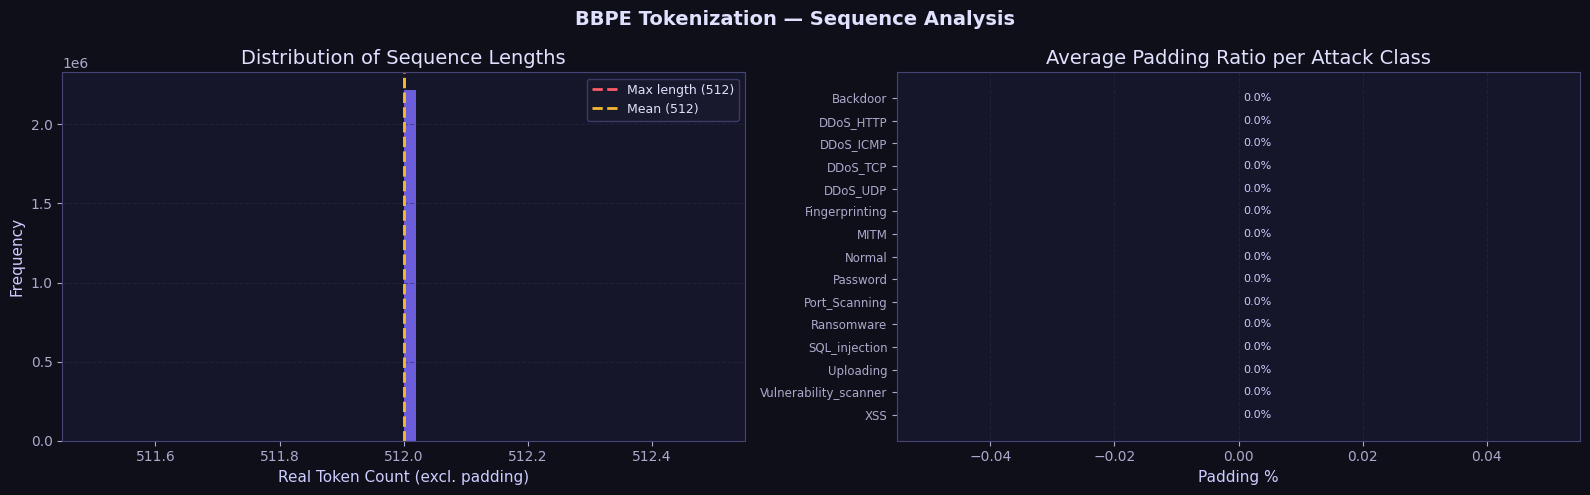

💾 Saved → ..\outputs\figures\N4/bbpe_sequence_analysis.png


In [15]:
# ── Figure 1: Sequence length distribution ─────────────────────────────────────
seq_lengths_np = seq_lengths.numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BBPE Tokenization — Sequence Analysis',
             fontsize=14, fontweight='bold', color='#e0e0ff')

# Histogram of real token counts
ax1 = axes[0]
ax1.hist(seq_lengths_np, bins=50, color=ACCENT, edgecolor='none', alpha=0.85)
ax1.axvline(x=MAX_SEQ_LEN, color=RED, linewidth=2,
            linestyle='--', label=f'Max length ({MAX_SEQ_LEN})')
ax1.axvline(x=seq_lengths_np.mean(), color=YELLOW, linewidth=2,
            linestyle='--', label=f'Mean ({seq_lengths_np.mean():.0f})')
ax1.set_xlabel('Real Token Count (excl. padding)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Sequence Lengths')
ax1.legend(fontsize=9)
ax1.grid(axis='y')

# Padding ratio per class
ax2 = axes[1]
padding_by_class = []
class_names      = []
for idx in range(len(label_map)):
    mask  = labels == idx
    if mask.sum() > 0:
        avg_real  = attn_masks[mask].sum(dim=1).float().mean().item()
        pad_ratio = 1.0 - (avg_real / MAX_SEQ_LEN)
        padding_by_class.append(pad_ratio * 100)
        class_names.append(label_map.get(str(idx), label_map.get(int(idx))))

colors = PALETTE[:len(class_names)]
bars   = ax2.barh(range(len(class_names)), padding_by_class,
                  color=colors, edgecolor='none')
ax2.set_yticks(range(len(class_names)))
ax2.set_yticklabels(class_names, fontsize=8.5)
ax2.set_xlabel('Padding %')
ax2.set_title('Average Padding Ratio per Attack Class')
ax2.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8, color='#ccccff')
ax2.invert_yaxis()
ax2.grid(axis='x')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'bbpe_sequence_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/bbpe_sequence_analysis.png')

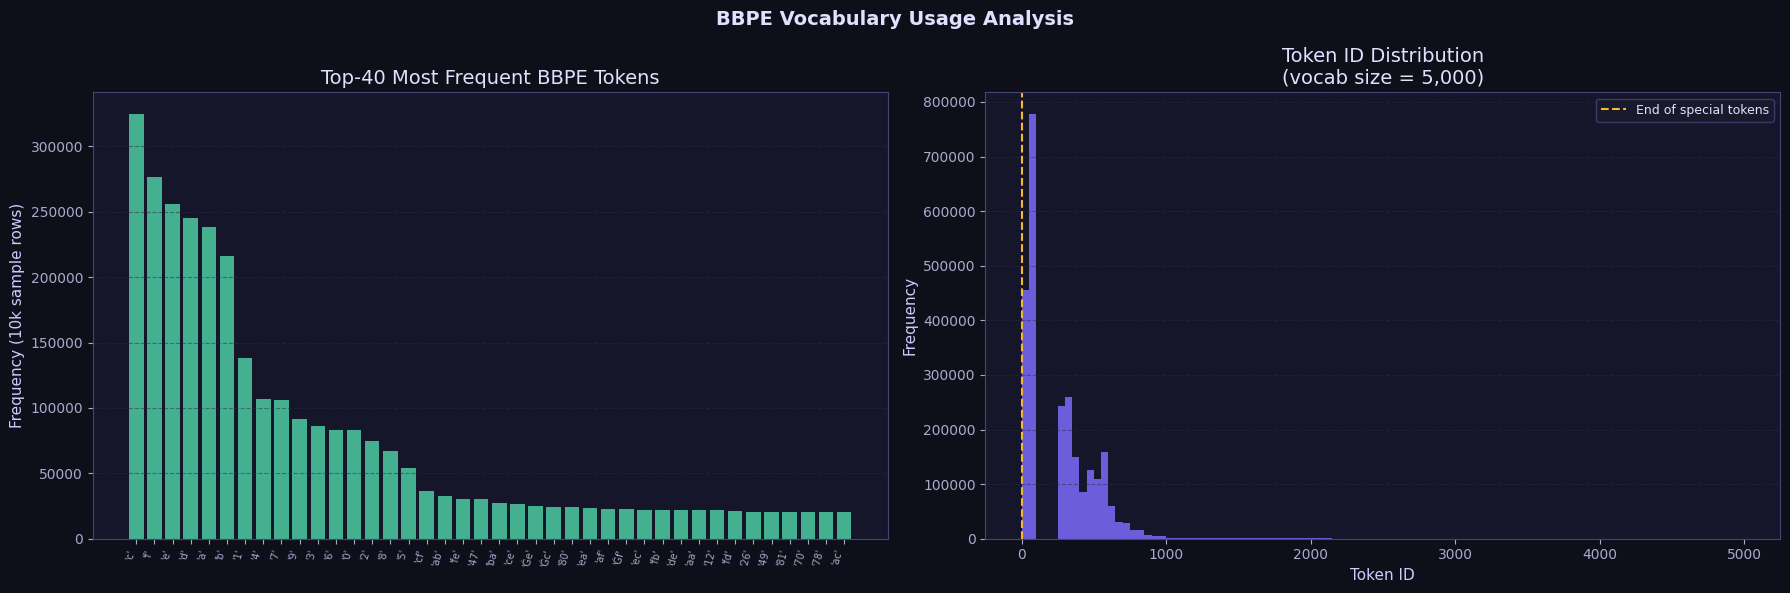

💾 Saved → ..\outputs\figures\N4/bbpe_token_frequency.png


In [13]:
# ── Figure 2: Token ID frequency distribution ─────────────────────────────────
# Sample 10k rows for speed
sample_ids = input_ids[:10_000].flatten().numpy()
# Exclude padding token
pad_id     = tokenizer.token_to_id('<pad>')
sample_ids = sample_ids[sample_ids != pad_id]

token_freq = Counter(sample_ids.tolist())
top_tokens = token_freq.most_common(40)
tok_ids    = [t[0] for t in top_tokens]
tok_counts = [t[1] for t in top_tokens]
tok_labels = [tokenizer.id_to_token(i) or f'id={i}' for i in tok_ids]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('BBPE Vocabulary Usage Analysis',
             fontsize=14, fontweight='bold', color='#e0e0ff')

# Top-40 most frequent tokens
ax1 = axes[0]
bars = ax1.bar(range(40), tok_counts, color=GREEN, edgecolor='none', alpha=0.85)
ax1.set_xticks(range(40))
ax1.set_xticklabels(
    [repr(t[:6]) if t else str(tok_ids[i]) for i, t in enumerate(tok_labels)],
    rotation=75, ha='right', fontsize=7
)
ax1.set_ylabel('Frequency (10k sample rows)')
ax1.set_title('Top-40 Most Frequent BBPE Tokens')
ax1.grid(axis='y')

# Token ID range distribution (histogram)
ax2 = axes[1]
all_flat = input_ids[:5_000].flatten().numpy()
all_flat = all_flat[all_flat != pad_id]
ax2.hist(all_flat, bins=100, color=ACCENT, edgecolor='none', alpha=0.85)
ax2.set_xlabel('Token ID')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Token ID Distribution\n(vocab size = {actual_vocab_size:,})')
ax2.axvline(x=len(SPECIAL_TOKENS), color=YELLOW, linewidth=1.5,
            linestyle='--', label='End of special tokens')
ax2.legend(fontsize=9)
ax2.grid(axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'bbpe_token_frequency.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/bbpe_token_frequency.png')

## 💾 Step 10 — Final Summary

In [ ]:
print('=' * 65)
print('  ✅  Notebook 04 — BBPE Tokenizer Complete')
print('=' * 65)
print()
print('📦 Artifacts produced:')
print(f'   tokenizer/corpus.txt           : {CORPUS_PATH.stat().st_size/1e6:.1f} MB')
print(f'   tokenizer/vocab.json           : {VOCAB_PATH.stat().st_size/1e3:.1f} KB')
print(f'   tokenizer/merges.txt           : {MERGES_PATH.stat().st_size/1e3:.1f} KB')
print(f'   tokenizer/label_map.json       : {label_map_path.stat().st_size/1e3:.1f} KB')
print(f'   data/processed/tokenized_sequences.pt : {OUTPUT_PATH.stat().st_size/1e6:.1f} MB')
print()
print('📐 Tokenizer configuration (paper-exact):')
print(f'   Algorithm       : ByteLevelBPETokenizer (GPT-2 style)')
print(f'   Vocabulary size : {actual_vocab_size:,}  (target: {VOCAB_SIZE:,})')
print(f'   Min frequency   : {MIN_FREQUENCY}')
print(f'   Max seq length  : {MAX_SEQ_LEN}  (truncation + padding)')
print(f'   Special tokens  : {SPECIAL_TOKENS}')
print()
print('📐 Tokenized dataset:')
print(f'   input_ids shape  : {tuple(data["input_ids"].shape)}')
print(f'   attn_mask shape  : {tuple(data["attention_mask"].shape)}')
print(f'   labels shape     : {tuple(data["labels"].shape)}')
print(f'   Num classes      : {len(label_map)}') 

  ✅  Notebook 04 — BBPE Tokenizer Complete

📦 Artifacts produced:
   tokenizer/corpus.txt           : 3369.7 MB
   tokenizer/vocab.json           : 57.9 KB
   tokenizer/merges.txt           : 28.0 KB
   tokenizer/label_map.json       : 0.3 KB
   data/processed/tokenized_sequences.pt : 18190.8 MB

📐 Tokenizer configuration (paper-exact):
   Algorithm       : ByteLevelBPETokenizer (GPT-2 style)
   Vocabulary size : 5,000  (target: 5,000)
   Min frequency   : 2
   Max seq length  : 512  (truncation + padding)
   Special tokens  : ['<s>', '<pad>', '</s>', '<unk>', '<mask>']

📐 Tokenized dataset:
   input_ids shape  : (2218386, 512)
   attn_mask shape  : (2218386, 512)
   labels shape     : (2218386,)
   Num classes      : 15


---
## ✅ Summary — Notebook 04 Outputs

| Artefact | Location |
|----------|----------|
| Training corpus | `tokenizer/corpus.txt` |
| Vocabulary file | `tokenizer/vocab.json` |
| Merge rules | `tokenizer/merges.txt` |
| Label mapping | `tokenizer/label_map.json` |
| Tokenized data | `data/processed/tokenized_sequences.pt` |
| Sequence analysis | `outputs/figures/bbpe_sequence_analysis.png` |
| Token frequency | `outputs/figures/bbpe_token_frequency.png` |

---

### Key Decisions (Paper-aligned)

| Parameter | Value | Source |
|-----------|-------|--------|
| Tokenizer | `ByteLevelBPETokenizer` | Paper Section III-D |
| Vocab size | 5,000 | Paper Section III-D |
| Min frequency | 2 | Paper Section III-D |
| Special tokens | `<s>`, `<pad>`, `</s>`, `<unk>`, `<mask>` | Paper Section III-D |
| Max seq length | 512 | Paper Table IV |
| Padding strategy | Fixed-length padding to 512 | Paper Section III-E |

---

### 🔜 Carry Forward to Notebook 05 — SecurityBERT Embedding

```python
data         = torch.load('data/processed/tokenized_sequences.pt')
input_ids    = data['input_ids']       # shape: (N, 512)
attn_masks   = data['attention_mask']  # shape: (N, 512)
labels       = data['labels']          # shape: (N,)
label_map    = data['label_map']       # {0: 'Backdoor', 1: 'DDoS_HTTP', ...}
vocab_size   = data['vocab_size']      # 5000
n_classes    = len(label_map)          # 15

# SecurityBERT embedding layer:
#   Word embeddings     : Embedding(30522, 128)
#   Position embeddings : Embedding(512, 128)
#   Token type embeds   : Embedding(2, 128)
#   → Input to 4 BERT encoder layers
```

In [3]:
# ── Count Total Tokens in Dataset ────────────────────────────

# 1. Total tokens (including [PAD] tokens) - literally rows × max_seq_len
total_slots = input_ids.numel()

# 2. Total valid tokens (excluding [PAD] tokens / zeros)
# Since attention_mask is 1 for real tokens and 0 for padding, 
# summing it gives the exact integer count of actual valid tokens.
total_valid_tokens = attention_mask.sum().item()

# 3. Total sequences (number of packets/rows)
total_sequences = input_ids.shape[0]

print("📊 Token Analysis")
print("──────────────────────────────────────────")
print(f"Total Sequences (Rows) : {total_sequences:,}")
print(f"Total Token Slots      : {total_slots:,} tokens")
print(f"Actual Valid Tokens    : {int(total_valid_tokens):,} tokens")
print(f"Padding Tokens         : {int(total_slots - total_valid_tokens):,} tokens")


NameError: name 'input_ids' is not defined